# Bike Availability Modeling



# Part 1 Feature pairs check


Loaded: final_merged_data.csv.gz
Shape after filter: (298946, 25)
Top 20 by |correlation|:
bikes_1d_mean          0.720048
bikes_7d_mean          0.591207
capacity               0.205051
lon                    0.124585
humidity               0.011577
day                    0.003829
weekend                0.003756
temp                   0.002011
minute                -0.000847
weekday               -0.000935
number                -0.001356
pressure              -0.002130
hour                  -0.004754
lat                   -0.137569
num_docks_available   -0.717459
stno                        NaN
year                        NaN
month                       NaN
Name: num_bikes_available, dtype: float64
bikes_1d_mean corr = 0.720048
bikes_7d_mean corr = 0.591207


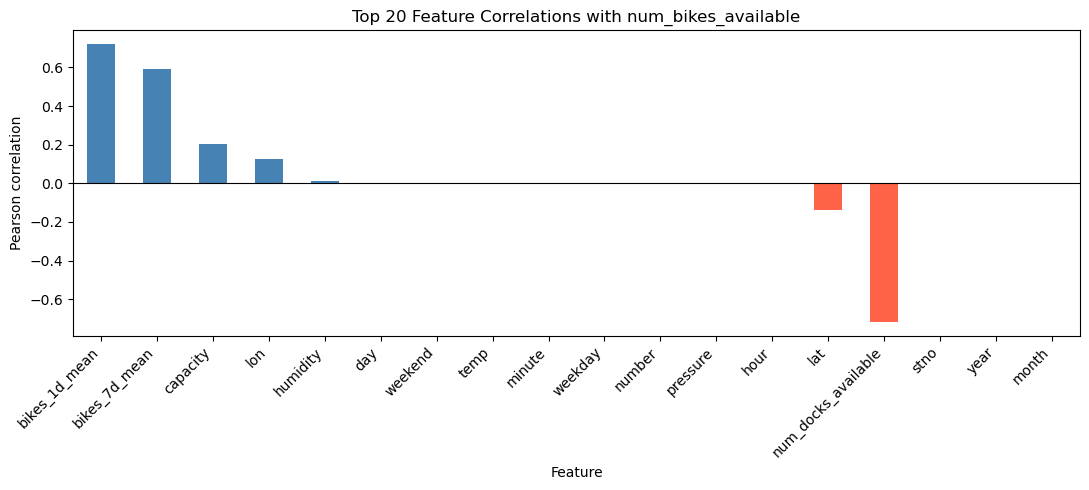

In [33]:
# Part 1: Feature Pair Check【中文详细注释版】
# 目标：
# - 读取原始数据；
# - 构造最小天气/时间特征（保留 temp / humidity / pressure）；
# - 在特征检查阶段加入 lag：bikes_1d_mean、bikes_7d_mean；
# - 删除冗余天气原始列；
# - 快速查看与目标变量的相关性 Top20。

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 每 10 分钟一条记录：1 天 144 条，1 周 1008 条
INTERVALS_PER_DAY = 144
INTERVALS_PER_WEEK = 1008

# 1) 读取数据（兼容项目根目录 / machine_learning 子目录）
candidates = [Path('final_merged_data.csv.gz'), Path('machine_learning/final_merged_data.csv.gz')]
raw_path = next((x for x in candidates if x.exists()), None)
if raw_path is None:
    raise FileNotFoundError('Cannot find final_merged_data.csv.gz')
df_raw = pd.read_csv(raw_path)

# 2) 字段标准化：统一站点编号列名为 number（后续建模统一使用）
if 'number' not in df_raw.columns and 'station_id' in df_raw.columns:
    df_raw = df_raw.rename(columns={'station_id': 'number'})

# 3) 必需列检查：缺列时立即报错，避免后续隐式失败
required = [
    'max_air_temperature_celsius', 'min_air_temperature_celsius',
    'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa',
    'max_relative_humidity_percent', 'min_relative_humidity_percent',
    'day', 'num_bikes_available', 'last_reported', 'number','num_docks_available'
]
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

# 4) 构造轻量天气特征（保留 temp / pressure / humidity）
# errors='coerce'：异常字符转 NaN，防止类型错误中断流程
df_raw['temp'] = (
    pd.to_numeric(df_raw['max_air_temperature_celsius'], errors='coerce')
    + pd.to_numeric(df_raw['min_air_temperature_celsius'], errors='coerce')
) / 2

df_raw['pressure'] = (
    pd.to_numeric(df_raw['max_barometric_pressure_hpa'], errors='coerce')
    + pd.to_numeric(df_raw['min_barometric_pressure_hpa'], errors='coerce')
) / 2

# humidity 与 Part2 保持一致：二值化（均值 > 90 记为 1）
hum_avg = (
    pd.to_numeric(df_raw['max_relative_humidity_percent'], errors='coerce')
    + pd.to_numeric(df_raw['min_relative_humidity_percent'], errors='coerce')
) / 2
df_raw['humidity'] = (hum_avg > 90).astype(int)

# 5) 构造最小时间标签 weekday/weekend
# 说明：这里使用 day % 7 的近似写法，只用于轻量筛查，不是严格日历星期
day_num = pd.to_numeric(df_raw['day'], errors='coerce')
df_raw['weekday'] = day_num % 7
df_raw['weekend'] = df_raw['weekday'].isin([5, 6]).astype(int)

# 6) 先构造 lag 特征（防泄漏：shift(1) 后 rolling）
# 这样当前行不会用到当前时刻的 num_bikes_available。
df_raw['last_reported'] = pd.to_datetime(df_raw['last_reported'], errors='coerce')
df_raw['number'] = pd.to_numeric(df_raw['number'], errors='coerce')
df_raw['num_bikes_available'] = pd.to_numeric(df_raw['num_bikes_available'], errors='coerce')

lag_base = df_raw.dropna(subset=['last_reported', 'number', 'num_bikes_available']).copy()
# 记录原始行索引，后面计算完 lag 要按这个索引回写到 df_raw
lag_base['_orig_idx'] = lag_base.index
lag_base['number'] = lag_base['number'].astype(int)
lag_base = lag_base.sort_values(['number', 'last_reported']).reset_index(drop=True)

g = lag_base.groupby('number')['num_bikes_available']
lag_base['bikes_1d_mean'] = g.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean()
)
lag_base['bikes_7d_mean'] = g.transform(
    lambda s: s.shift(1).rolling(INTERVALS_PER_WEEK, min_periods=INTERVALS_PER_DAY).mean()
)

# 与 Part 2 保持一致：lag 缺失先用站点均值，再用全局均值
station_mean = lag_base.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(lag_base['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_7d_mean']:
    lag_base[c] = lag_base[c].fillna(station_mean).fillna(global_mean)

# 回写到 df_raw（按原始行索引对齐，避免错位）
df_raw.loc[lag_base['_orig_idx'], 'bikes_1d_mean'] = lag_base['bikes_1d_mean'].values
df_raw.loc[lag_base['_orig_idx'], 'bikes_7d_mean'] = lag_base['bikes_7d_mean'].values

# 7) 清理原始天气大列，仅保留 temp（降低冗余和噪声）
# 注意：这里不会删除 bikes_1d_mean / bikes_7d_mean。
weather_keywords = [
    'temperature', 'humidity', 'pressure', 'barometric', 'weather',
    'wind', 'rain', 'snow', 'soil', 'earth', 'grass', 'quality_indicator'
]
def is_raw_weather_col(col: str) -> bool:
    lc = col.lower()
    return any(k in lc for k in weather_keywords)

keep_weather = {'temp', 'pressure', 'humidity'}
drop_cols = [c for c in df_raw.columns if is_raw_weather_col(c) and c not in keep_weather]
df_model = df_raw.drop(columns=drop_cols, errors='ignore').copy()

# 8) 计算与目标变量的 Pearson 相关系数（仅数值列）
num_cols = df_model.select_dtypes(include=['number']).columns.tolist()
feature_cols = [c for c in num_cols if c != 'num_bikes_available']
corr = (
    df_model[feature_cols + ['num_bikes_available']]
    .corr(numeric_only=True)['num_bikes_available']
    .drop('num_bikes_available')
)

# 9) 提取绝对值 Top20，并按原符号排序，便于观察正负方向
top20 = corr.abs().sort_values(ascending=False).head(20).index
plot_data = corr.loc[top20].sort_values(ascending=False)

print(f'Loaded: {raw_path}')
print(f'Shape after filter: {df_model.shape}')
print('Top 20 by |correlation|:')
print(plot_data)

# 确认 lag 已加入 Part1 特征检查
for lag_col in ['bikes_1d_mean', 'bikes_7d_mean']:
    if lag_col in corr.index:
        print(f'{lag_col} corr = {corr[lag_col]:.6f}')
    else:
        print(f'{lag_col} not found in numeric corr columns')

# 10) 可视化：正相关蓝色，负相关红色
plt.figure(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in plot_data.values]
plot_data.plot(kind='bar', color=colors)
plt.title('Top 20 Feature Correlations with num_bikes_available')
plt.xlabel('Feature')
plt.ylabel('Pearson correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()





# Part 1 conclution:
 从相关性上,需要保留的特征为:
- 日期:day,hour,minute,
- 天气:temp,pressure,humidity
- 地理:lon,lat,number
- 车辆数据:bikes_1d_mean,bikes_7d_mean,capacity
- Ps:num_bikes_available 和num_docks_available是互补的,所以特征不保留,防止数据泄露造成过拟合.

## Part 2: Data Cleaning
Load raw data, build time/weather/lag features, and produce `df_clean`.


In [34]:
import pandas as pd
from pathlib import Path

# Part 2: Data Cleaning
# 目标：
# - 基础清洗（时间/编号/目标字段）；
# - 构造简化天气特征 temp/pressure/humidity；
# - 构造防泄漏 lag 特征；
# - 输出 df_clean、features、target、data_cleaned.csv。

# 每 10 分钟一条记录：1 天 144 条，1 周 1008 条
INTERVALS_PER_DAY = 144
INTERVALS_PER_WEEK = 1008

# 1) 读取数据（兼容两种运行目录）
candidates = [Path('final_merged_data.csv.gz'), Path('machine_learning/final_merged_data.csv.gz')]
raw_path = next((x for x in candidates if x.exists()), None)
if raw_path is None:
    raise FileNotFoundError('Cannot find final_merged_data.csv.gz')
df = pd.read_csv(raw_path)

# 2) 统一站点编号列名
if 'number' not in df.columns and 'station_id' in df.columns:
    df = df.rename(columns={'station_id': 'number'})

# 3) 基础必需列检查
required = ['last_reported', 'number', 'num_bikes_available', 'day', 'hour', 'minute', 'lon', 'lat']
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}')

# 4) 类型转换：非法值转缺失，随后统一删除
# - last_reported -> datetime
# - number/target/day/hour/minute -> numeric
df['last_reported'] = pd.to_datetime(df['last_reported'], errors='coerce')
for c in ['number', 'num_bikes_available', 'day', 'hour', 'minute', 'lon', 'lat']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=required).copy()
df[['number', 'day', 'hour', 'minute']] = df[['number', 'day', 'hour', 'minute']].astype(int)

# 模型字段标准化：
# - 目标列使用 available_bikes（由原始 num_bikes_available 转换）
# - 地理列使用 lng（由原始 lon 转换）和 lat
df['available_bikes'] = df['num_bikes_available']
df['lng'] = df['lon']

# 5) 天气列检查并构造紧凑天气特征
weather_req = [
    'max_air_temperature_celsius', 'min_air_temperature_celsius',
    'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa',
    'max_relative_humidity_percent', 'min_relative_humidity_percent',
]
missing_weather = [c for c in weather_req if c not in df.columns]
if missing_weather:
    raise KeyError(f'Missing required weather columns: {missing_weather}')

# 温度/气压：max-min 平均值
# 湿度：简化成二值变量（均值 > 90 记为 1）
df['temp'] = (df['max_air_temperature_celsius'] + df['min_air_temperature_celsius']) / 2
df['pressure'] = (df['max_barometric_pressure_hpa'] + df['min_barometric_pressure_hpa']) / 2
df['humidity'] = (((df['max_relative_humidity_percent'] + df['min_relative_humidity_percent']) / 2) > 90).astype(int)

# 6) 防泄漏 lag 特征
# 关键：先按站点+时间排序，再 shift(1) 后 rolling
# 这样“当前行特征”只来自“过去”，不会把当前目标值泄漏进去
df = df.sort_values(['number', 'last_reported']).reset_index(drop=True)
g = df.groupby('number')['num_bikes_available']
df['bikes_1d_mean'] = g.transform(lambda s: s.shift(1).rolling(INTERVALS_PER_DAY, min_periods=INTERVALS_PER_DAY // 2).mean())
df['bikes_7d_mean'] = g.transform(lambda s: s.shift(1).rolling(INTERVALS_PER_WEEK, min_periods=INTERVALS_PER_DAY).mean())

# 7) 缺失填充：先站点均值，再全局均值（保证训练输入完整）
station_mean = df.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(df['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_7d_mean']:
    df[c] = df[c].fillna(station_mean).fillna(global_mean)

# 8) 最小可用特征集合（与后续模型 cell 对齐）
features = [
    'number', 'capacity', 'day', 'hour', 'minute',
    'temp', 'pressure', 'humidity',
    'lng', 'lat',
    'bikes_1d_mean', 'bikes_7d_mean',
]
target = 'available_bikes'

missing_final = [c for c in features + [target] if c not in df.columns]
if missing_final:
    raise KeyError(f'Missing required final columns: {missing_final}')

# 9) 生成 df_clean（含 last_reported 供时间切分）并导出 CSV（特征+目标）
df_clean = (
    df[features + [target, 'last_reported']]
    .dropna()
    .sort_values('last_reported')
    .reset_index(drop=True)
)
df_clean[features + [target]].to_csv(raw_path.parent / 'data_cleaned.csv', index=False)

print(f'Loaded: {raw_path}')
print(f'Cleaned shape: {df_clean.shape}')
print(f'Saved: {raw_path.parent / "data_cleaned.csv"}')
display(df_clean.head(3))




Loaded: final_merged_data.csv.gz
Cleaned shape: (298946, 14)
Saved: data_cleaned.csv


,number,capacity,day,hour,minute,temp,pressure,humidity,lng,lat,bikes_1d_mean,bikes_7d_mean,available_bikes,last_reported
0,31,20,1,0,10,13.955,1002.41,0,-6.265125,53.350930,10.652259,10.652259,3,2024-12-01 00:10:00
1,13,30,1,0,10,13.955,1002.41,0,-6.252825,53.336075,12.959508,12.959508,0,2024-12-01 00:10:00
2,4,20,1,0,10,13.955,1002.41,0,-6.272976,53.346874,10.550703,10.550703,11,2024-12-01 00:10:00


## Part 3: Model Training
Train linear regression using `df_clean`:
- Use one-hot encoding for `station_id`
- Use time-ordered 70/30 split

# 1. Liner Regression with Lag Features

In [ ]:
# Linear Regression with Lag Features（简化版）
# 说明：
# - 使用 Part 2 生成的 features / target
# - 按时间顺序切分（前 70% 训练，后 30% 测试）
# - number 做 One-Hot，其余特征直接数值输入

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# 1) 按时间排序，避免未来信息泄漏到训练集
data = df_clean.sort_values('last_reported').reset_index(drop=True)

# 2) 时间切分（70/30）
split_idx = int(len(data) * 0.7)
train_df, test_df = data.iloc[:split_idx], data.iloc[split_idx:]
X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

# 3) 预处理：站点编号 one-hot，其他特征原样透传
cat_cols = ['number']
num_cols = [c for c in features if c not in cat_cols]

model = Pipeline([
    ('preprocess', ColumnTransformer([
        ('station_ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols),
    ])),
    ('regressor', LinearRegression()),
])

# 4) 训练 + 预测
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5) 评估
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Test MAE : {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Test R²  : {r2:.4f}')




Test MAE : 4.0780
Test RMSE: 5.2787
Test R²  : 0.6566
Train/Test rows: 209262/89684


In [36]:
# Minimal feature ablation: compare prediction with one extra lag feature at a time
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

lag_candidates = [
    'bikes_1d_mean',
    'bikes_7d_mean',
    'bikes_7d_std',
    'bikes_same_slot_prev_day',
    'bikes_same_slot_prev_week',
    'has_prev_week',
]

base_features = [c for c in features if c not in lag_candidates]


def evaluate(feat_cols, label):
    data_eval = df_clean[feat_cols + [target]].dropna().copy()
    split_idx = int(len(data_eval) * 0.7)
    train_data = data_eval.iloc[:split_idx]
    test_data = data_eval.iloc[split_idx:]

    X_train, y_train = train_data[feat_cols], train_data[target]
    X_test, y_test = test_data[feat_cols], test_data[target]

    categorical_features = ['number']
    numeric_features = [c for c in feat_cols if c not in categorical_features]

    model = Pipeline([
        ('preprocess', ColumnTransformer([
            ('station_ohe', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features),
        ])),
        ('regressor', LinearRegression()),
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'feature_used': label,
        'n_rows': len(data_eval),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
    }


results = [evaluate(base_features, 'baseline(no_lag)')]

for col in lag_candidates:
    if col in df_clean.columns:
        results.append(evaluate(base_features + [col], col))

result_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
display(result_df)



,feature_used,n_rows,MAE,R2
0,bikes_1d_mean,298946,3.912202,0.677077
1,bikes_7d_mean,298946,5.839752,0.339261
2,baseline(no_lag),298946,6.212583,0.259186


# 2.SVR
# 3.Random 
# 4.Forest 
# 5.Ridge 
# 6.Regression
# 7.Decision Tree

# Part C: Analyse model performance
 1.Linear Regression
 2.SVR
 3.Random 
 4.Forest 
 5.Ridge 
 6.Regression
 7.Decision Tree

## 1. Linear Regression
This model performs well in short-term forecasts (Test R² ≈ 0.684, MAE ≈ 3.91), but the lower cross-validation results (CV R² ≈ 0.545) indicate that its generalization across time windows remains limited.
Performance improvements rely primarily on lagged features rather than static weather or time variables.

# Part D :Prediction applied on Flask API

In [1]:
import os
from datetime import datetime
import requests
import pandas as pd

# ---- Target model features (reuse `features` from earlier cleaning cell when available) ----
MODEL_FEATURES = features if ('features' in globals() and isinstance(features, list) and len(features) > 0) else [
    'number', 'lat', 'lon', 'capacity', 'day', 'hour', 'minute', 'very_humid',
    'average_temperature_celsius', 'average_pressure_hpa',
    'bikes_1d_mean', 'bikes_7d_mean', 'bikes_7d_std',
    'bikes_same_slot_prev_day', 'bikes_same_slot_prev_week', 'has_prev_week'
]

def _get_key(name, fallback_config_attr=None):
    v = os.getenv(name)
    if v:
        return v
    if fallback_config_attr:
        try:
            import config
            return getattr(config, fallback_config_attr)
        except Exception:
            return None
    return None

def fetch_openweather_sample(lat=53.3498, lon=-6.2603):
    api_key = _get_key('OPENWEATHER_API_KEY', 'OPENWEATHER_API_KEY')
    if not api_key:
        return {'ok': False, 'error': 'Missing OPENWEATHER_API_KEY', 'sample': {}}

    url = 'https://api.openweathermap.org/data/2.5/forecast'
    params = {'lat': lat, 'lon': lon, 'appid': api_key, 'units': 'metric', 'cnt': 1}
    try:
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()
        rec = (data.get('list') or [{}])[0]
        return {'ok': True, 'error': None, 'sample': rec}
    except Exception as e:
        return {'ok': False, 'error': str(e), 'sample': {}}

def fetch_jcd_station_sample(contract='dublin'):
    api_key = _get_key('JCDECAUX_API_KEY', 'JCDECAUX_API_KEY')
    if not api_key:
        return {'ok': False, 'error': 'Missing JCDECAUX_API_KEY', 'sample': {}}

    url = 'https://api.jcdecaux.com/vls/v1/stations'
    params = {'contract': contract, 'apiKey': api_key}
    try:
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        arr = r.json()
        rec = arr[0] if isinstance(arr, list) and len(arr) > 0 else {}
        return {'ok': True, 'error': None, 'sample': rec}
    except Exception as e:
        return {'ok': False, 'error': str(e), 'sample': {}}

ow = fetch_openweather_sample()
jcd = fetch_jcd_station_sample(contract=os.getenv('JCDECAUX_CONTRACT', 'dublin'))

print('OpenWeather status:', 'OK' if ow['ok'] else f"FAILED ({ow['error']})")
print('JCD status:', 'OK' if jcd['ok'] else f"FAILED ({jcd['error']})")

mapping = [
    # Directly from JCD
    {'model_feature': 'number', 'source_api': 'JCD', 'source_field': 'number', 'status': 'direct', 'rule': 'number = number'},
    {'model_feature': 'lat', 'source_api': 'JCD', 'source_field': 'position.lat', 'status': 'direct', 'rule': 'lat = position.lat'},
    {'model_feature': 'lon', 'source_api': 'JCD', 'source_field': 'position.lng', 'status': 'direct', 'rule': 'lon = position.lng'},
    {'model_feature': 'capacity', 'source_api': 'JCD', 'source_field': 'bike_stands', 'status': 'direct', 'rule': 'capacity = bike_stands'},

    # Derived from timestamp (usually request datetime or forecast dt)
    {'model_feature': 'day', 'source_api': 'OpenWeather', 'source_field': 'list[0].dt / dt_txt', 'status': 'derived', 'rule': 'day = datetime.day'},
    {'model_feature': 'hour', 'source_api': 'OpenWeather', 'source_field': 'list[0].dt / dt_txt', 'status': 'derived', 'rule': 'hour = datetime.hour'},
    {'model_feature': 'minute', 'source_api': 'OpenWeather', 'source_field': 'list[0].dt / dt_txt', 'status': 'derived', 'rule': 'minute = datetime.minute'},

    # Weather-derived features
    {'model_feature': 'average_temperature_celsius', 'source_api': 'OpenWeather', 'source_field': 'list[0].main.temp (or temp_min/temp_max)', 'status': 'derived', 'rule': 'use main.temp or (temp_min+temp_max)/2'},
    {'model_feature': 'average_pressure_hpa', 'source_api': 'OpenWeather', 'source_field': 'list[0].main.pressure', 'status': 'direct', 'rule': 'average_pressure_hpa = main.pressure'},
    {'model_feature': 'very_humid', 'source_api': 'OpenWeather', 'source_field': 'list[0].main.humidity', 'status': 'derived', 'rule': 'very_humid = int(humidity >= 90)'},

    # Not available from OpenWeather + JCD realtime APIs alone
    {'model_feature': 'bikes_1d_mean', 'source_api': 'History DB', 'source_field': 'past num_bikes_available', 'status': 'unavailable_from_realtime_api', 'rule': 'rolling mean over previous 1 day per station'},
    {'model_feature': 'bikes_7d_mean', 'source_api': 'History DB', 'source_field': 'past num_bikes_available', 'status': 'unavailable_from_realtime_api', 'rule': 'rolling mean over previous 7 days per station'},
    {'model_feature': 'bikes_7d_std', 'source_api': 'History DB', 'source_field': 'past num_bikes_available', 'status': 'unavailable_from_realtime_api', 'rule': 'rolling std over previous 7 days per station'},
    {'model_feature': 'bikes_same_slot_prev_day', 'source_api': 'History DB', 'source_field': 'same slot t-1d', 'status': 'unavailable_from_realtime_api', 'rule': 'lag 1 day at same time slot'},
    {'model_feature': 'bikes_same_slot_prev_week', 'source_api': 'History DB', 'source_field': 'same slot t-7d', 'status': 'unavailable_from_realtime_api', 'rule': 'lag 7 days at same time slot'},
    {'model_feature': 'has_prev_week', 'source_api': 'History DB', 'source_field': 'is prev-week lag present', 'status': 'unavailable_from_realtime_api', 'rule': '1 if prev-week exists else 0'},
]

mapping_df = pd.DataFrame(mapping)
mapping_df = mapping_df[mapping_df['model_feature'].isin(MODEL_FEATURES)].copy()

print('\n=== Feature Mapping (Model vs APIs) ===')
display(mapping_df)

unmapped = sorted(set(MODEL_FEATURES) - set(mapping_df['model_feature']))
if unmapped:
    print('\n[Warning] Features not covered in mapping table:', unmapped)

unavailable = mapping_df.loc[mapping_df['status'] == 'unavailable_from_realtime_api', 'model_feature'].tolist()
print('\n=== Cannot be obtained directly from OpenWeather + JCD realtime APIs ===')
print(unavailable if unavailable else 'None')

print('\n=== Example raw API snippets (first record) ===')
print('OpenWeather list[0] keys:', sorted((ow['sample'] or {}).keys()))
print('JCD station keys:', sorted((jcd['sample'] or {}).keys()))



OpenWeather status: OK
JCD status: OK

=== Feature Mapping (Model vs APIs) ===


,model_feature,source_api,source_field,status,rule
0,station_id,JCD,number,direct,station_id = number
1,lat,JCD,position.lat,direct,lat = position.lat
2,lon,JCD,position.lng,direct,lon = position.lng
3,capacity,JCD,bike_stands,direct,capacity = bike_stands
4,day,OpenWeather,list[0].dt / dt_txt,derived,day = datetime.day
5,hour,OpenWeather,list[0].dt / dt_txt,derived,hour = datetime.hour
6,minute,OpenWeather,list[0].dt / dt_txt,derived,minute = datetime.minute
7,average_temperature_celsius,OpenWeather,list[0].main.temp (or temp_min/temp_max),derived,use main.temp or (temp_min+temp_max)/2
8,average_pressure_hpa,OpenWeather,list[0].main.pressure,direct,average_pressure_hpa = main.pressure
9,very_humid,OpenWeather,list[0].main.humidity,derived,very_humid = int(humidity >= 90)



=== Cannot be obtained directly from OpenWeather + JCD realtime APIs ===
['bikes_1d_mean', 'bikes_7d_mean', 'bikes_7d_std', 'bikes_same_slot_prev_day', 'bikes_same_slot_prev_week', 'has_prev_week']

=== Example raw API snippets (first record) ===
OpenWeather list[0] keys: ['clouds', 'dt', 'dt_txt', 'main', 'pop', 'sys', 'visibility', 'weather', 'wind']
JCD station keys: ['address', 'available_bike_stands', 'available_bikes', 'banking', 'bike_stands', 'bonus', 'contract_name', 'last_update', 'name', 'number', 'position', 'status']


In [ ]:
import os
import requests
import pandas as pd

# ---- Target model features (reuse `features` from earlier cleaning cell when available) ----
MODEL_FEATURES = features if ('features' in globals() and isinstance(features, list) and len(features) > 0) else [
    'number', 'capacity', 'day', 'hour', 'minute',
    'temp', 'pressure', 'humidity',
    'lng', 'lat',
    'bikes_1d_mean', 'bikes_7d_mean'
]

def _get_key(name, fallback_config_attr=None):
    v = os.getenv(name)
    if v:
        return v
    if fallback_config_attr:
        try:
            import config
            return getattr(config, fallback_config_attr)
        except Exception:
            return None
    return None

def fetch_openweather_sample(lat=53.3498, lon=-6.2603):
    api_key = _get_key('OPENWEATHER_API_KEY', 'OPENWEATHER_API_KEY')
    if not api_key:
        return {'ok': False, 'error': 'Missing OPENWEATHER_API_KEY', 'sample': {}}

    url = 'https://api.openweathermap.org/data/2.5/forecast'
    params = {'lat': lat, 'lon': lon, 'appid': api_key, 'units': 'metric', 'cnt': 1}
    try:
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        data = r.json()
        rec = (data.get('list') or [{}])[0]
        return {'ok': True, 'error': None, 'sample': rec}
    except Exception as e:
        return {'ok': False, 'error': str(e), 'sample': {}}

def fetch_jcd_station_sample(contract='dublin'):
    api_key = _get_key('JCDECAUX_API_KEY', 'JCDECAUX_API_KEY')
    if not api_key:
        return {'ok': False, 'error': 'Missing JCDECAUX_API_KEY', 'sample': {}}

    url = 'https://api.jcdecaux.com/vls/v1/stations'
    params = {'contract': contract, 'apiKey': api_key}
    try:
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        arr = r.json()
        rec = arr[0] if isinstance(arr, list) and len(arr) > 0 else {}
        return {'ok': True, 'error': None, 'sample': rec}
    except Exception as e:
        return {'ok': False, 'error': str(e), 'sample': {}}

def map_openweather_to_features(forecast_item):
    """Map OpenWeather forecast record to model weather features."""
    main = (forecast_item or {}).get('main', {}) or {}
    return {
        'temp': float(main.get('temp', 0.0)),
        'pressure': float(main.get('pressure', 0.0)),
        'humidity': float(main.get('humidity', 0.0)),
    }

ow = fetch_openweather_sample()
jcd = fetch_jcd_station_sample(contract=os.getenv('JCDECAUX_CONTRACT', 'dublin'))

print('OpenWeather status:', 'OK' if ow['ok'] else f"FAILED ({ow['error']})")
print('JCD status:', 'OK' if jcd['ok'] else f"FAILED ({jcd['error']})")

mapped_weather = map_openweather_to_features(ow.get('sample', {}))
print('Mapped weather feature preview:')
display(pd.DataFrame([mapped_weather]))

mapping = [
    {'feature': 'number', 'source_api': 'JCD', 'source_field': 'number', 'status': 'direct', 'rule': 'number = number'},
    {'feature': 'capacity', 'source_api': 'JCD', 'source_field': 'bike_stands', 'status': 'direct', 'rule': 'capacity = bike_stands'},
    {'feature': 'day', 'source_api': 'Request/OpenWeather', 'source_field': 'dt or request datetime', 'status': 'derived', 'rule': 'day = datetime.day'},
    {'feature': 'hour', 'source_api': 'Request/OpenWeather', 'source_field': 'dt or request datetime', 'status': 'derived', 'rule': 'hour = datetime.hour'},
    {'feature': 'minute', 'source_api': 'Request/OpenWeather', 'source_field': 'dt or request datetime', 'status': 'derived', 'rule': 'minute = datetime.minute'},
    {'feature': 'temp', 'source_api': 'OpenWeather', 'source_field': 'list[0].main.temp', 'status': 'direct', 'rule': 'temperature in Celsius (`units=metric`) from main.temp'},
    {'feature': 'pressure', 'source_api': 'OpenWeather', 'source_field': 'list[0].main.pressure', 'status': 'direct', 'rule': 'pressure (hPa) from main.pressure'},
    {'feature': 'humidity', 'source_api': 'OpenWeather', 'source_field': 'list[0].main.humidity', 'status': 'direct', 'rule': 'humidity (%) from main.humidity'},
    {'feature': 'bikes_1d_mean', 'source_api': 'History DB', 'source_field': 'past num_bikes_available', 'status': 'unavailable_from_realtime_api', 'rule': 'rolling mean over previous 1 day per station'},
    {'feature': 'bikes_7d_mean', 'source_api': 'History DB', 'source_field': 'past num_bikes_available', 'status': 'unavailable_from_realtime_api', 'rule': 'rolling mean over previous 7 days per station'},
]

mapping_df = pd.DataFrame(mapping)
mapping_df['required_by_model'] = mapping_df['feature'].isin(MODEL_FEATURES)

print('
=== Feature Mapping (API -> Features) ===')
display(mapping_df)

required_df = mapping_df[mapping_df['required_by_model']].copy()
print('
=== Required model features only ===')
display(required_df)

unmapped = sorted(set(MODEL_FEATURES) - set(mapping_df['feature']))
if unmapped:
    print('
[Warning] Required model features missing in mapping table:', unmapped)

unavailable_required = required_df.loc[required_df['status'] == 'unavailable_from_realtime_api', 'feature'].tolist()
print('
=== Required features not directly obtainable from OpenWeather + JCD realtime APIs ===')
print(unavailable_required if unavailable_required else 'None')

print('
=== Example raw API keys (first record) ===')
print('OpenWeather list[0] keys:', sorted((ow.get('sample') or {}).keys()))
print('JCD station keys:', sorted((jcd.get('sample') or {}).keys()))





OpenWeather status: OK
JCD status: OK

Mapped weather feature preview:


,average_temperature_celsius,average_pressure_hpa,average_humidity_percent,very_humid
0,10.01,1017.0,71.0,0



=== Feature Mapping (API -> Features) ===


,feature,source_api,source_field,status,rule,required_by_model
0,station_id,JCD,number,direct,station_id = number,True
1,lat,JCD,position.lat,direct,lat = position.lat,False
2,lon,JCD,position.lng,direct,lon = position.lng,False
3,capacity,JCD,bike_stands,direct,capacity = bike_stands,True
4,day,Request/OpenWeather,dt or request datetime,derived,day = datetime.day,True
5,hour,Request/OpenWeather,dt or request datetime,derived,hour = datetime.hour,True
6,minute,Request/OpenWeather,dt or request datetime,derived,minute = datetime.minute,True
7,average_temperature_celsius,OpenWeather,list[0].main.temp,direct,temperature in Celsius (`units=metric`) from m...,True
8,average_pressure_hpa,OpenWeather,list[0].main.pressure,direct,pressure (hPa) from main.pressure,True
9,average_humidity_percent,OpenWeather,list[0].main.humidity,direct,humidity (%) from main.humidity,False



=== Required model features only ===


,feature,source_api,source_field,status,rule,required_by_model
0,station_id,JCD,number,direct,station_id = number,True
3,capacity,JCD,bike_stands,direct,capacity = bike_stands,True
4,day,Request/OpenWeather,dt or request datetime,derived,day = datetime.day,True
5,hour,Request/OpenWeather,dt or request datetime,derived,hour = datetime.hour,True
6,minute,Request/OpenWeather,dt or request datetime,derived,minute = datetime.minute,True
7,average_temperature_celsius,OpenWeather,list[0].main.temp,direct,temperature in Celsius (`units=metric`) from m...,True
8,average_pressure_hpa,OpenWeather,list[0].main.pressure,direct,pressure (hPa) from main.pressure,True
10,very_humid,OpenWeather,list[0].main.humidity,derived,very_humid = int(average_humidity_percent >= 90),True
11,bikes_1d_mean,History DB,past num_bikes_available,unavailable_from_realtime_api,rolling mean over previous 1 day per station,True
12,bikes_7d_mean,History DB,past num_bikes_available,unavailable_from_realtime_api,rolling mean over previous 7 days per station,True



=== Required features not directly obtainable from OpenWeather + JCD realtime APIs ===
['bikes_1d_mean', 'bikes_7d_mean']

=== Example raw API keys (first record) ===
OpenWeather list[0] keys: ['clouds', 'dt', 'dt_txt', 'main', 'pop', 'rain', 'sys', 'visibility', 'weather', 'wind']
JCD station keys: ['address', 'available_bike_stands', 'available_bikes', 'banking', 'bike_stands', 'bonus', 'contract_name', 'last_update', 'name', 'number', 'position', 'status']
